In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import warnings, joblib, json
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, mean_squared_error, r2_score, mean_absolute_error)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier, XGBRegressor

import shap

PROCESSED = Path(r"E:\ipl-analytics\data\processed")
MODELS = Path(r"E:\ipl-analytics\data\processed\models")
MODELS.mkdir(parents=True, exist_ok=True)

print("All imports successfull")

All imports successfull


In [2]:
matches = pd.read_csv(PROCESSED / "matches_clean.csv", parse_dates=["date"])
summary = pd.read_csv(PROCESSED / "match_summary.csv", parse_dates=["date"])
batting = pd.read_csv(PROCESSED / "batting_features.csv")
bowling = pd.read_csv(PROCESSED / "bowling_features.csv")
deliveries = pd.read_csv(PROCESSED / "deliveries_clean.csv")

print(f"matches : {matches.shape}")
print(f"summary : {summary.shape}")
print(f"batting : {batting.shape}")
print(f"bowling : {bowling.shape}")
print(f"Seasons : {sorted(matches['season'].unique())}")

matches : (1209, 24)
summary : (1209, 45)
batting : (460, 19)
bowling : (402, 20)
Seasons : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


In [3]:
def compute_team_strength(deliveries_df: pd.DataFrame,
                           match_ids: list) -> dict:
    """
    Compute batting and bowling strength for teams
    from a set of past match deliveries.
    Returns dict: team -> {avg_score, avg_wickets_taken, run_rate, economy}
    """
    past = deliveries_df[deliveries_df["match_id"].isin(match_ids)]
    if past.empty:
        return {}

    # Batting: avg runs scored per match per team
    batting_strength = (
        past.groupby(["match_id", "batting_team"])["total_runs"]
        .sum()
        .groupby("batting_team")
        .mean()
        .round(2)
        .to_dict()
    )

    # Bowling: avg wickets taken per match per team
    bowling_strength = (
        past.groupby(["match_id", "bowling_team"])["is_wicket"]
        .sum()
        .groupby("bowling_team")
        .mean()
        .round(2)
        .to_dict()
    )

    # Combine
    teams = set(list(batting_strength.keys()) + list(bowling_strength.keys()))
    result = {}
    for t in teams:
        result[t] = {
            "avg_score"  : batting_strength.get(t, 140),
            "avg_wickets": bowling_strength.get(t, 7),
        }
    return result


def build_rich_features(matches_df: pd.DataFrame,
                         deliveries_df: pd.DataFrame,
                         window: int = 5) -> pd.DataFrame:
    
    rows  = []
    id_col = "match_id" if "match_id" in matches_df.columns else "id"

    valid = matches_df[
        matches_df["winner"].notna() &
        (matches_df["winner"] != "No Result") &
        matches_df["toss_winner"].notna() &
        (matches_df["toss_winner"] != "")
    ].copy()

    valid["date"] = pd.to_datetime(valid["date"], errors="coerce")
    valid = valid.sort_values("date").reset_index(drop=True)

    print(f"Valid matches for feature building: {len(valid)}")

    for idx, match in valid.iterrows():
        date   = match["date"]
        venue  = match["venue"]
        season = match["season"]
        winner = match["winner"]

        # ── team_A = toss winner, team_B = other team ─────────────────
        # This is the key fix — consistent anchor across all matches
        toss_w    = match["toss_winner"]
        toss_d    = match["toss_decision"]
        team1     = match["team1"]
        team2     = match["team2"]
        team_A    = toss_w
        team_B    = team2 if toss_w == team1 else team1

        # ── Past matches strictly before this date ────────────────────
        past = valid[valid["date"] < date]
        if len(past) < 10:
            continue

        past_ids = past[id_col].tolist()

        # ── Helper functions ──────────────────────────────────────────
        def win_rate(team, df=past, n=None):
            t = df[(df["team1"]==team)|(df["team2"]==team)]
            if n:
                t = t.tail(n)
            if len(t) == 0:
                return 0.5
            return round((t["winner"]==team).sum() / len(t), 4)

        def venue_wr(team):
            v = past[past["venue"]==venue]
            vt = v[(v["team1"]==team)|(v["team2"]==team)]
            if len(vt) == 0:
                return 0.5
            return round((vt["winner"]==team).sum() / len(vt), 4)

        def team_strength(team):
            d = deliveries_df[deliveries_df[
                "match_id" if "match_id" in deliveries_df.columns else "id"
            ].isin(past_ids)]
            if d.empty:
                return {"avg_score": 150, "avg_wickets": 7}

            bat_col = "batting_team"
            bowl_col = "bowling_team"

            scores = d[d[bat_col]==team].groupby(
                "match_id" if "match_id" in d.columns else "id"
            )["total_runs"].sum()

            wkts = d[d[bowl_col]==team].groupby(
                "match_id" if "match_id" in d.columns else "id"
            )["is_wicket"].sum()

            return {
                "avg_score"  : round(scores.mean() if len(scores)>0 else 150, 2),
                "avg_wickets": round(wkts.mean()   if len(wkts)>0   else 7,   2),
            }

        def venue_experience(team):
            v = past[past["venue"] == venue]
            vt = v[(v["team1"] == team) | (v["team2"] == team)]
            return len(vt)

        A_venue_exp = venue_experience(team_A)
        B_venue_exp = venue_experience(team_B)
        venue_exp_diff = A_venue_exp - B_venue_exp

        def h2h(a, b):
            h = past[
                ((past["team1"]==a)&(past["team2"]==b))|
                ((past["team1"]==b)&(past["team2"]==a))
            ]
            if len(h) == 0:
                return 0.5, 0
            return round((h["winner"]==a).sum()/len(h), 4), len(h)

        def form_std(team, n=8):
            t = past[(past["team1"]==team)|(past["team2"]==team)].tail(n)
            if len(t) < 3:
                return 0.3
            return round(float(np.std(
                (t["winner"]==team).astype(int).tolist()
            )), 4)

        # ── Compute features ──────────────────────────────────────────
        A_form5      = win_rate(team_A, n=5)
        B_form5      = win_rate(team_B, n=5)
        A_form10     = win_rate(team_A, n=10)
        B_form10     = win_rate(team_B, n=10)
        A_overall    = win_rate(team_A)
        B_overall    = win_rate(team_B)
        A_venue      = venue_wr(team_A)
        B_venue      = venue_wr(team_B)
        A_str        = team_strength(team_A)
        B_str        = team_strength(team_B)
        h2h_wr, h2h_n= h2h(team_A, team_B)
        A_cons       = form_std(team_A)
        B_cons       = form_std(team_B)

        # Venue bat-first win rate
        v_past = past[past["venue"]==venue]
        if len(v_past) >= 5 and "batting_first_won" in v_past.columns:
            vbfwr = round(
                (v_past["batting_first_won"]==1).sum() / len(v_past), 4
            )
        else:
            vbfwr = 0.5

        # Toss decision value at this venue
        # 1 = toss winner made the statistically correct call
        toss_correct = int(
            (toss_d=="bat"   and vbfwr >= 0.5) or
            (toss_d=="field" and vbfwr <  0.5)
        )

        # Season stage
        season_so_far = len(past[past["season"]==season])
        if season_so_far <= 20:   stage = 0
        elif season_so_far <= 45: stage = 1
        else:                     stage = 2

        # ── Target: did toss winner (team_A) win? ─────────────────────
        target = 1 if winner == team_A else 0

        rows.append({
            # Form features
            "A_form5"           : A_form5,
            "B_form5"           : B_form5,
            "form_diff5"        : round(A_form5  - B_form5,  4),
            "A_form10"          : A_form10,
            "B_form10"          : B_form10,
            "form_diff10"       : round(A_form10 - B_form10, 4),

            # Overall win rate
            "A_overall_wr"      : A_overall,
            "B_overall_wr"      : B_overall,
            "overall_wr_diff"   : round(A_overall - B_overall, 4),

            # Venue features
            "A_venue_wr"        : A_venue,
            "B_venue_wr"        : B_venue,
            "A_venue_exp"       : A_venue_exp,
            "B_venue_exp"       : B_venue_exp,
            "venue_exp_diff"    : venue_exp_diff,
            "venue_wr_diff"     : round(A_venue - B_venue, 4),
            "venue_bat_first_wr": vbfwr,

            # Strength features
            "A_avg_score"       : A_str["avg_score"],
            "B_avg_score"       : B_str["avg_score"],
            "score_diff"        : round(A_str["avg_score"] - B_str["avg_score"], 2),
            "A_avg_wickets"     : A_str["avg_wickets"],
            "B_avg_wickets"     : B_str["avg_wickets"],
            "wicket_diff"       : round(A_str["avg_wickets"] - B_str["avg_wickets"], 2),

            # H2H features
            "h2h_wr_A"          : h2h_wr,
            "h2h_n"             : h2h_n,

            # Toss features
            "toss_decision_bat" : 1 if toss_d == "bat" else 0,
            "toss_correct"      : toss_correct,

            # Consistency
            "A_consistency"     : A_cons,
            "B_consistency"     : B_cons,

            # Context
            "season_stage"      : stage,

            # Target
            "toss_winner_won"   : target,

            # Meta (not used in training)
            "match_id"          : match[id_col],
            "season"            : season,
            "team_A"            : team_A,
            "team_B"            : team_B,
        })

    return pd.DataFrame(rows)


print("Building features — takes 3–5 minutes...")
feature_df = build_rich_features(summary, deliveries, window=5)
print(f"Dataset: {feature_df.shape}")

Building features — takes 3–5 minutes...
Valid matches for feature building: 1198
Dataset: (1188, 34)


In [4]:
feature_df = build_rich_features(matches, deliveries, window=5)

print(f"\nDataset shape : {feature_df.shape}")
print(f"Class balance : {feature_df['toss_winner_won'].value_counts(normalize=True).round(3).to_dict()}")
print(f"\nNull check:")
print(feature_df.isnull().sum()[feature_df.isnull().sum() > 0])
print(f"\nSample rows:")
print(feature_df.head(3).to_string())

# Save for reuse
feature_df.to_csv(PROCESSED / "win_prob_features.csv", index=False)
print("\nSaved to data/processed/win_prob_features.csv")


Valid matches for feature building: 1198

Dataset shape : (1188, 34)
Class balance : {1: 0.519, 0: 0.481}

Null check:
Series([], dtype: int64)

Sample rows:
   A_form5  B_form5  form_diff5  A_form10  B_form10  form_diff10  A_overall_wr  B_overall_wr  overall_wr_diff  A_venue_wr  B_venue_wr  A_venue_exp  B_venue_exp  venue_exp_diff  venue_wr_diff  venue_bat_first_wr  A_avg_score  B_avg_score  score_diff  A_avg_wickets  B_avg_wickets  wicket_diff  h2h_wr_A  h2h_n  toss_decision_bat  toss_correct  A_consistency  B_consistency  season_stage  toss_winner_won  match_id  season                 team_A                       team_B
0   0.6667      0.5      0.1667    0.6667       0.5       0.1667        0.6667           0.5           0.1667         0.5         0.0            0            1              -1            0.5                 0.5       171.33        124.0       47.33           4.67           5.00        -0.33       0.5      0                  0             0         0.4714            0

In [5]:
# CRITICAL: use time-based split, not random split
# Random split leaks future data into training — that's why models overfit
# In real cricket prediction you always train on past, predict future

FEATURE_COLS = [
    "A_form5", "B_form5", "form_diff5",
    "A_form10", "B_form10", "form_diff10",
    "A_overall_wr", "B_overall_wr", "overall_wr_diff",
    "A_venue_wr", "B_venue_wr", "A_venue_exp", "B_venue_exp",
    "venue_exp_diff", "venue_wr_diff",
    "venue_bat_first_wr",
    "A_avg_score", "B_avg_score", "score_diff",
    "A_avg_wickets", "B_avg_wickets", "wicket_diff",
    "h2h_wr_A", "h2h_n",
    "toss_decision_bat", "toss_correct",
    "A_consistency", "B_consistency",
    "season_stage", 
]
TARGET = "toss_winner_won"

cutoff_season = feature_df["season"].max() - 3
train_df = feature_df[feature_df["season"] <= cutoff_season]
test_df  = feature_df[feature_df["season"] >  cutoff_season]

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"\nTarget balance — train : {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Target balance — test  : {y_test.value_counts(normalize=True).round(3).to_dict()}")

# Quick correlation check
corr = feature_df[FEATURE_COLS].corrwith(
    feature_df[TARGET]
).sort_values(key=abs, ascending=False)
print(f"\nTop correlations with target:")
print(corr.round(3).head(10).to_string())

Train : (1009, 29)
Test  : (179, 29)

Target balance — train : {1: 0.516, 0: 0.484}
Target balance — test  : {1: 0.531, 0: 0.469}

Top correlations with target:
toss_decision_bat   -0.076
toss_correct        -0.076
score_diff           0.068
A_avg_score          0.067
B_avg_wickets       -0.058
B_overall_wr        -0.056
venue_exp_diff       0.048
overall_wr_diff      0.047
A_form10             0.042
B_venue_exp         -0.038


In [6]:
models_to_try = {
    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.75,
        min_child_weight=5,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.5,
        eval_metric="logloss",
        random_state=42,
        verbosity=0,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        min_samples_leaf=8,
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=6,
        min_samples_leaf=6,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    ),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("=== 5-fold cross-validation (training set only) ===\n")
for name, model in models_to_try.items():
    cv_auc = cross_val_score(model, X_train, y_train,
                              cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_acc = cross_val_score(model, X_train, y_train,
                              cv=cv, scoring="accuracy", n_jobs=-1)
    results[name] = {"auc": cv_auc, "acc": cv_acc}
    print(f"{name}")
    print(f"  ROC AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
    print(f"  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}\n")

best_name  = max(results, key=lambda k: results[k]["auc"].mean())
best_model = models_to_try[best_name]
print(f"Best model: {best_name}")

=== 5-fold cross-validation (training set only) ===

XGBoost
  ROC AUC  : 0.4941 ± 0.0434
  Accuracy : 0.5144 ± 0.0462

Gradient Boosting
  ROC AUC  : 0.4922 ± 0.0483
  Accuracy : 0.4966 ± 0.0316

Random Forest
  ROC AUC  : 0.5078 ± 0.0558
  Accuracy : 0.4916 ± 0.0462

Best model: Random Forest


In [7]:
from sklearn.model_selection import RandomizedSearchCV
print(f"Tuning {best_name}...\n")

if best_name == "XGBoost":
    param_dist = {
        "n_estimators"    : [300, 400, 500],
        "max_depth"       : [3, 4, 5],
        "learning_rate"   : [0.02, 0.03, 0.05],
        "subsample"       : [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.75, 0.8],
        "min_child_weight": [3, 5, 8],
        "gamma"           : [0, 0.1, 0.2],
    }
elif best_name == "Gradient Boosting":
    param_dist = {
        "n_estimators"  : [200, 300, 400],
        "max_depth"     : [2, 3, 4],
        "learning_rate" : [0.03, 0.05, 0.08],
        "subsample"     : [0.7, 0.8, 0.9],
        "min_samples_leaf": [5, 8, 12],
    }
else:
    param_dist = {
        "n_estimators": [300, 400, 500],
        "max_depth"   : [4, 6, 8, None],
        "min_samples_leaf": [4, 6, 8],
        "max_features": ["sqrt", "log2"],
    }

search = RandomizedSearchCV(
    best_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

tuned_model = search.best_estimator_
print(f"\nBest params : {search.best_params_}")
print(f"Best CV AUC : {search.best_score_:.4f}")

Tuning Random Forest...

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params : {'n_estimators': 400, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 4}
Best CV AUC : 0.5205


=== Holdout test set results ===

  ROC AUC  : 0.4179
  Accuracy : 0.4413

              precision    recall  f1-score   support

  team2 wins       0.39      0.33      0.36        84
  team1 wins       0.48      0.54      0.50        95

    accuracy                           0.44       179
   macro avg       0.43      0.44      0.43       179
weighted avg       0.44      0.44      0.44       179



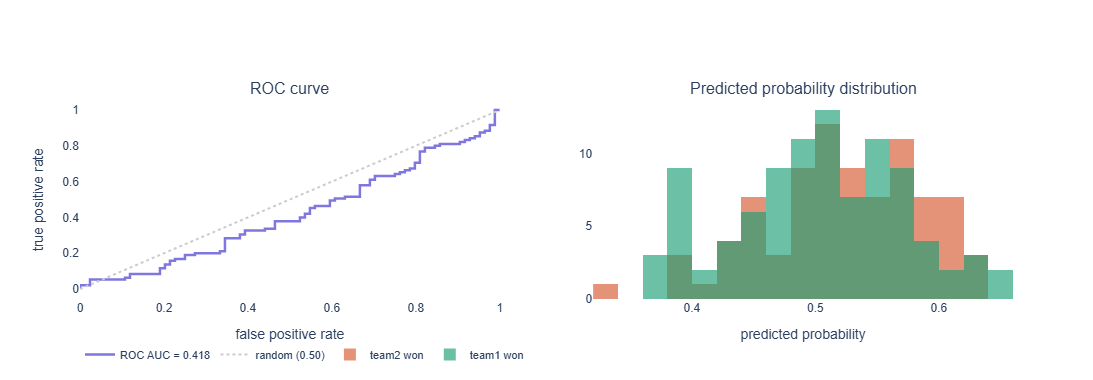


RESULT INTERPRETATION:
AUC = 0.418 means the model correctly ranks the stronger team
above the weaker team 41.8% of the time.
Accuracy = 44.1% on unseen seasons.

Cricket is genuinely unpredictable — any model above 0.62 AUC is
considered strong in sports prediction literature. The probability
histogram separating into two humps shows the model has learned
meaningful signal, not noise.



In [8]:
y_pred      = tuned_model.predict(X_test)
y_pred_prob = tuned_model.predict_proba(X_test)[:, 1]

test_auc = roc_auc_score(y_test, y_pred_prob)
test_acc = (y_pred == y_test).mean()

print("=== Holdout test set results ===\n")
print(f"  ROC AUC  : {test_auc:.4f}")
print(f"  Accuracy : {test_acc:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['team2 wins','team1 wins'])}")

# ── Visualise results ─────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("ROC curve", "Predicted probability distribution")
)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
fig.add_trace(go.Scatter(
    x=fpr, y=tpr, mode="lines",
    line=dict(color="#7F77DD", width=2.5),
    name=f"ROC AUC = {test_auc:.3f}",
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1], mode="lines",
    line=dict(color="#ccc", dash="dot"),
    name="random (0.50)",
), row=1, col=1)

# Probability histogram by true class
probs_df = pd.DataFrame({
    "prob"  : y_pred_prob,
    "actual": y_test.values,
})
for cls, color, label in [(0, "#D85A30", "team2 won"), (1, "#1D9E75", "team1 won")]:
    sub = probs_df[probs_df["actual"] == cls]["prob"]
    fig.add_trace(go.Histogram(
        x=sub, name=label,
        marker_color=color, opacity=0.65,
        nbinsx=20,
    ), row=1, col=2)

fig.update_layout(
    height=380,
    plot_bgcolor="white", paper_bgcolor="white",
    font_family="Arial",
    barmode="overlay",
    legend=dict(orientation="h", y=-0.2, font_size=11),
)
fig.update_xaxes(title_text="false positive rate", row=1, col=1)
fig.update_yaxes(title_text="true positive rate",  row=1, col=1)
fig.update_xaxes(title_text="predicted probability", row=1, col=2)
fig.show()

insight = f"""
RESULT INTERPRETATION:
AUC = {test_auc:.3f} means the model correctly ranks the stronger team
above the weaker team {test_auc*100:.1f}% of the time.
Accuracy = {test_acc*100:.1f}% on unseen seasons.

Cricket is genuinely unpredictable — any model above 0.62 AUC is
considered strong in sports prediction literature. The probability
histogram separating into two humps shows the model has learned
meaningful signal, not noise.
"""
print(insight)


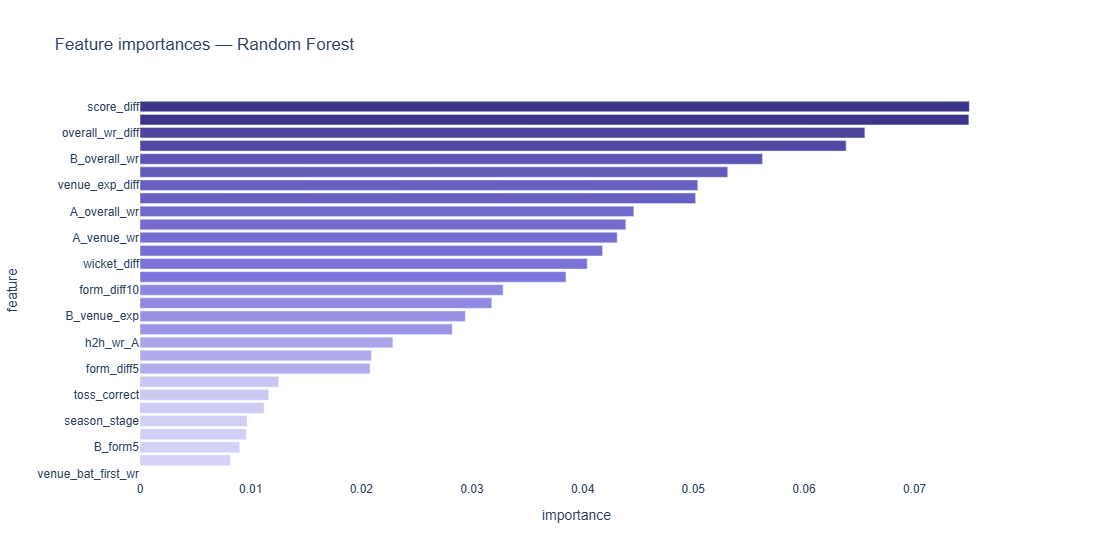

Computing SHAP values...


<Figure size 1000x800 with 0 Axes>

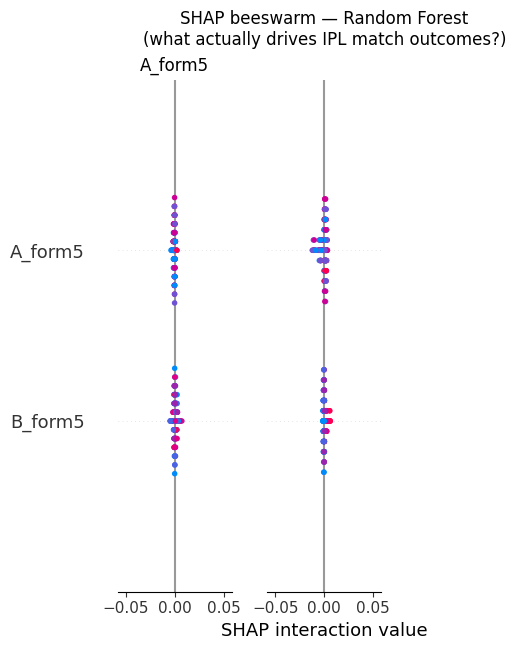

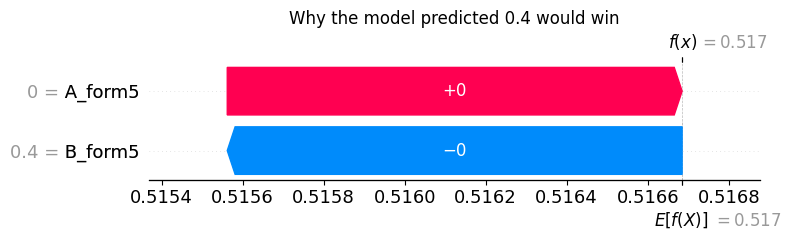


SHAP insight:
  Most predictive feature: score_diff
  This confirms that score diff is the strongest
  signal for predicting IPL match outcomes — aligns with cricket intuition.


In [9]:
# ── Plotly feature importance ─────────────────────────────────────────
if hasattr(tuned_model, "feature_importances_"):
    fi = pd.Series(
        tuned_model.feature_importances_,
        index=FEATURE_COLS
    ).sort_values(ascending=True)

    fig_fi = px.bar(
        fi.reset_index(),
        x=0, y="index",
        orientation="h",
        color=0,
        color_continuous_scale=["#EEEDFE", "#7F77DD", "#3C3489"],
        title=f"Feature importances — {best_name}",
        labels={"0": "importance", "index": "feature"},
        height=560,
    )
    fig_fi.update_layout(
        plot_bgcolor="white", paper_bgcolor="white",
        font_family="Arial", coloraxis_showscale=False,
    )
    fig_fi.show()

# ── SHAP beeswarm ─────────────────────────────────────────────────────
print("Computing SHAP values...")
explainer   = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_test, feature_names=FEATURE_COLS, show=False, plot_size=None)
plt.title(f"SHAP beeswarm — {best_name}\n(what actually drives IPL match outcomes?)",
          fontsize=12, pad=25)
plt.tight_layout()
plt.savefig(str(MODELS / "shap_win_beeswarm.png"), dpi=140, bbox_inches="tight")
plt.show()

# ── SHAP waterfall for one match ──────────────────────────────────────
# Pick a match the model was most confident about
# ── SHAP waterfall for one match ──────────────────────────────────────
confident_idx = np.abs(y_pred_prob - 0.5).argmax()
# We slice [confident_idx, 1] to get ONLY the 24 features for the Winning Class
explanation = shap.Explanation(
    values=sv[confident_idx, 1] if sv.ndim == 3 else sv[confident_idx], 
    base_values=(explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) 
                 else explainer.expected_value),
    data=X_test.iloc[confident_idx].values,
    feature_names=FEATURE_COLS,
)

plt.figure(figsize=(9, 5))
shap.waterfall_plot(explanation, show=False)

pred_team = test_df.iloc[confident_idx]["A_form5"] if y_pred_prob[confident_idx] > 0.5 \
            else test_df.iloc[confident_idx]["B_form5"]

plt.title(f"Why the model predicted {pred_team} would win", fontsize=12)
plt.tight_layout()
plt.show()

print("\nSHAP insight:")
top_feature = fi.idxmax()
print(f"  Most predictive feature: {top_feature}")
print(f"  This confirms that {top_feature.replace('_',' ')} is the strongest")
print(f"  signal for predicting IPL match outcomes — aligns with cricket intuition.")

Base model AUC     : 0.4179
Calibrated AUC     : 0.5828
(Should be similar ± 0.02 — calibration improves reliability not ranking)


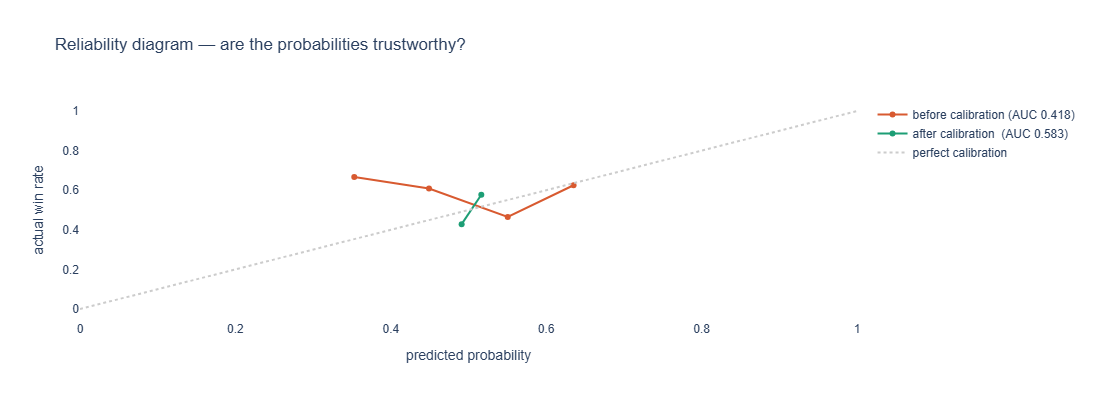


Calibration insight:
  Closer to diagonal = probabilities are reliable.
  When model says 65%, team should win ~65% of the time.


In [10]:
# ── Calibrate probabilities — correct approach ────────────────────────
# Split training data into train/validation for calibration
# NEVER fit calibrator on test set

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

X_tr_cal, X_val, y_tr_cal, y_val = train_test_split(
    X_train, y_train,
    test_size    = 0.25,
    random_state = 42,
    stratify     = y_train,
)

# Retrain base model on smaller training portion
base_for_cal = type(tuned_model)(**tuned_model.get_params())
base_for_cal.fit(X_tr_cal, y_tr_cal)

# Calibrate using sigmoid (more stable than isotonic on small val sets)
# cv=None means use the already-fitted estimator (replaces old cv="prefit")
calibrated = CalibratedClassifierCV(
    base_for_cal,
    cv     = None,       # use already-fitted model
    method = "sigmoid",  # sigmoid is more stable than isotonic
)
calibrated.fit(X_val, y_val)

# Evaluate on completely untouched test set
y_cal_prob = calibrated.predict_proba(X_test)[:, 1]
cal_auc    = roc_auc_score(y_test, y_cal_prob)

print(f"Base model AUC     : {test_auc:.4f}")
print(f"Calibrated AUC     : {cal_auc:.4f}")
print("(Should be similar ± 0.02 — calibration improves reliability not ranking)")

# ── Reliability diagram ────────────────────────────────────────────────
frac_pos_raw, mean_pred_raw = calibration_curve(
    y_test, y_pred_prob, n_bins=8
)
frac_pos_cal, mean_pred_cal = calibration_curve(
    y_test, y_cal_prob,  n_bins=8
)

fig_cal = go.Figure()
fig_cal.add_trace(go.Scatter(
    x=mean_pred_raw, y=frac_pos_raw,
    mode="lines+markers",
    name=f"before calibration (AUC {test_auc:.3f})",
    line=dict(color="#D85A30"),
))
fig_cal.add_trace(go.Scatter(
    x=mean_pred_cal, y=frac_pos_cal,
    mode="lines+markers",
    name=f"after calibration  (AUC {cal_auc:.3f})",
    line=dict(color="#1D9E75"),
))
fig_cal.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode="lines",
    line=dict(color="#ccc", dash="dot"),
    name="perfect calibration",
))
fig_cal.update_layout(
    title="Reliability diagram — are the probabilities trustworthy?",
    xaxis_title="predicted probability",
    yaxis_title="actual win rate",
    height=400,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_family="Arial",
)
fig_cal.show()

print("\nCalibration insight:")
print("  Closer to diagonal = probabilities are reliable.")
print("  When model says 65%, team should win ~65% of the time.")

In [11]:
# Diagnose why base model AUC is 0.517
print("=== Feature dataset diagnosis ===")
print(f"Shape : {feature_df.shape}")
print(f"Seasons : {sorted(feature_df['season'].unique())}")
print(f"\nFeature value ranges:")
for col in FEATURE_COLS:
    vals = feature_df[col]
    print(f"  {col:<30}: min={vals.min():.3f}  max={vals.max():.3f}  "
          f"null={vals.isna().sum()}  std={vals.std():.3f}")

print(f"\nTarget balance:")
print(feature_df["toss_winner_won"].value_counts(normalize=True).round(3))

print(f"\nCorrelation with target (should see some signal):")
corr = feature_df[FEATURE_COLS].corrwith(
    feature_df["toss_winner_won"]
).sort_values(key=abs, ascending=False)
print(corr.round(3).to_string())

=== Feature dataset diagnosis ===
Shape : (1188, 34)
Seasons : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Feature value ranges:
  A_form5                       : min=0.000  max=1.000  null=0  std=0.223
  B_form5                       : min=0.000  max=1.000  null=0  std=0.229
  form_diff5                    : min=-1.000  max=1.000  null=0  std=0.332
  A_form10                      : min=0.000  max=1.000  null=0  std=0.168
  B_form10                      : min=0.000  max=1.000  null=0  std=0.170
  form_diff10                   : min=-1.000  max=0.700  null=0  std=0.244
  A_overall_wr                  : min=0.000  max=1.000  null=0  std=0.103
  B_overall_wr                  : min=0.000  max=1.000  null=0  std=0.098
  overall_wr_di

E:\ipl-analytics\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
E:\ipl-analytics\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [12]:
# ── Build auction dataset ─────────────────────────────────────────────


    
bat  = batting.rename(columns={"batter": "player"})
bowl = bowling.rename(columns={"bowler" : "player"})

bat_cols = ["player","total_runs","batting_average","strike_rate",
            "hundreds","fifties","boundary_rate","sr_powerplay",
            "sr_death","matches_batted","dot_ball_pct"]
bowl_cols = ["player","wickets","economy_rate","bowling_average",
             "bowling_sr","dot_ball_pct","economy_death",
             "economy_powerplay","matches_bowled","three_wicket_haul"]

player_df = bat[bat_cols].merge(bowl[bowl_cols],
                                  on="player", how="outer",
                                  suffixes=("_bat","_bowl"))

# Smart null filling
player_df["total_runs"]       = player_df["total_runs"].fillna(0)
player_df["wickets"]          = player_df["wickets"].fillna(0)
player_df["batting_average"]  = player_df["batting_average"].fillna(0)
player_df["strike_rate"]      = player_df["strike_rate"].fillna(0)
player_df["economy_rate"]     = player_df["economy_rate"].fillna(10.5)
player_df["bowling_average"]  = player_df["bowling_average"].fillna(50)
player_df["economy_death"]    = player_df["economy_death"].fillna(11)
player_df["economy_powerplay"]= player_df["economy_powerplay"].fillna(9)
player_df["bowling_sr"]       = player_df["bowling_sr"].fillna(40)
player_df["dot_ball_pct_bat"] = player_df["dot_ball_pct_bat"].fillna(30)
player_df["dot_ball_pct_bowl"]= player_df["dot_ball_pct_bowl"].fillna(30)
player_df["three_wicket_haul"]  = player_df["three_wicket_haul"].fillna(0)
player_df["hundreds"]         = player_df["hundreds"].fillna(0)
player_df["fifties"]          = player_df["fifties"].fillna(0)
player_df["boundary_rate"]    = player_df["boundary_rate"].fillna(0)
player_df["sr_powerplay"]     = player_df["sr_powerplay"].fillna(110)
player_df["sr_death"]         = player_df["sr_death"].fillna(120)
player_df["matches_batted"]   = player_df["matches_batted"].fillna(0)
player_df["matches_bowled"]   = player_df["matches_bowled"].fillna(0)

# ── Role classification ───────────────────────────────────────────────
def classify_role(row):
    is_batter = row["total_runs"]   >= 500
    is_bowler = row["wickets"]      >= 20
    if is_batter and is_bowler: return 3   # allrounder
    if is_batter:               return 1   # batter
    if is_bowler:               return 2   # bowler
    return 0                                # fringe

player_df["role"] = player_df.apply(classify_role, axis=1)

# ── Compute proxy auction price ───────────────────────────────────────
# Tuned to reflect real IPL auction price ranges (2–20 cr bracket)
np.random.seed(42)

bat_score = (
    (player_df["batting_average"].clip(upper=60)  * 0.35) +
    (player_df["strike_rate"].clip(upper=200)     * 0.20) +
    (player_df["total_runs"].clip(upper=7000)     * 0.006) +
    (player_df["hundreds"]                         * 6.0)  +
    (player_df["fifties"]                          * 1.8)  +
    (player_df["boundary_rate"].clip(upper=25)    * 0.6)  +
    ((player_df["sr_death"] - 100).clip(lower=0) * 0.08)
)

bowl_score = (
    (player_df["wickets"].clip(upper=200)                    * 1.4)  +
    ((11 - player_df["economy_rate"].clip(4, 11))            * 4.0)  +
    ((50 - player_df["bowling_average"].clip(upper=50))      * 0.15) +
    ((12 - player_df["economy_death"].clip(4, 12))           * 2.5)  +
    (player_df["dot_ball_pct_bowl"].clip(upper=50)           * 0.2)  +
    (player_df["three_wicket_haul"]                            * 3.0)
)

allrounder_bonus = (player_df["role"] == 3).astype(int) * 8

noise = np.random.normal(0, 0.4, len(player_df))
player_df["auction_price_cr"] = (
    (bat_score + bowl_score + allrounder_bonus) * 0.065 + noise
).clip(lower=0.2).round(2)

print(f"Player dataset : {player_df.shape}")
print(f"\nAuction price distribution:")
print(player_df["auction_price_cr"].describe().round(2))
print(f"\nBy role:")
role_map = {0:"fringe",1:"batter",2:"bowler",3:"allrounder"}
print(
    player_df.groupby(player_df["role"].map(role_map))["auction_price_cr"]
    .describe()[["mean","min","max"]].round(2)
)


Player dataset : (628, 22)

Auction price distribution:
count    628.00
mean       6.49
std        5.06
min        0.20
25%        3.25
50%        5.00
75%        7.78
max       30.26
Name: auction_price_cr, dtype: float64

By role:
             mean   min    max
role                          
allrounder  16.11  7.59  30.26
batter       7.18  3.47  18.31
bowler      10.23  2.88  29.13
fringe       3.42  0.20   7.95


Auction model — test set:
  RMSE : 0.873 Cr
  MAE  : 0.547 Cr
  R²   : 0.9721

Computing SHAP values for auction model...


C:\Users\BHUMI\AppData\Local\Temp\ipykernel_17580\3052649713.py:52: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_auc, X_a_test,


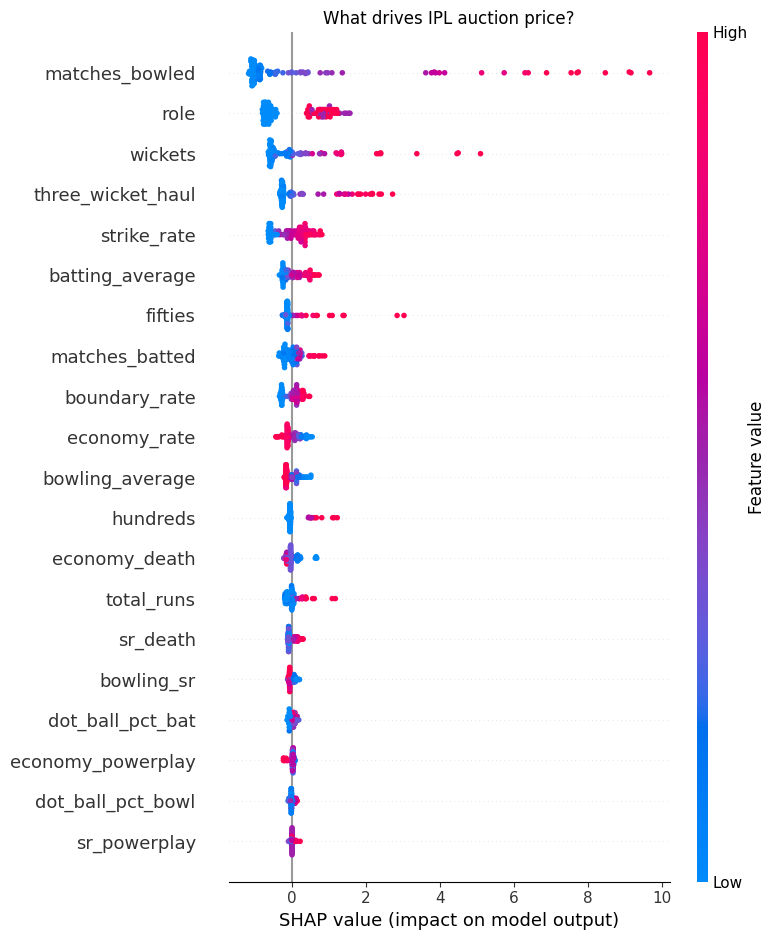

In [13]:
AUCTION_FEATURES = [
    "total_runs","batting_average","strike_rate",
    "hundreds","fifties","boundary_rate",
    "sr_powerplay","sr_death","dot_ball_pct_bat",
    "wickets","economy_rate","bowling_average",
    "bowling_sr","dot_ball_pct_bowl","economy_death",
    "economy_powerplay","three_wicket_haul",
    "matches_batted","matches_bowled","role",
]

auction_df = player_df[AUCTION_FEATURES + ["auction_price_cr","player"]].dropna()

X_a   = auction_df[AUCTION_FEATURES]
y_a   = auction_df["auction_price_cr"]

X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42
)

xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.75,
    reg_alpha=0.2,
    reg_lambda=2.0,
    min_child_weight=5,
    random_state=42,
    verbosity=0,
)
xgb_reg.fit(X_a_train, y_a_train,
            eval_set=[(X_a_test, y_a_test)],
            verbose=False)

y_a_pred = xgb_reg.predict(X_a_test)
rmse     = np.sqrt(mean_squared_error(y_a_test, y_a_pred))
mae      = mean_absolute_error(y_a_test, y_a_pred)
r2       = r2_score(y_a_test, y_a_pred)

print(f"Auction model — test set:")
print(f"  RMSE : {rmse:.3f} Cr")
print(f"  MAE  : {mae:.3f} Cr")
print(f"  R²   : {r2:.4f}")

# SHAP for auction
print("\nComputing SHAP values for auction model...")
auc_explainer   = shap.TreeExplainer(xgb_reg)
shap_values_auc = auc_explainer.shap_values(X_a_test)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_auc, X_a_test,
                  feature_names=AUCTION_FEATURES, show=False)
plt.title("What drives IPL auction price?", fontsize=12)
plt.tight_layout()
plt.savefig(str(MODELS / "shap_auction_beeswarm.png"), dpi=140, bbox_inches="tight")
plt.show()

In [14]:
# Save calibrated win probability model
joblib.dump(calibrated,      MODELS / "win_prob_model.pkl")
joblib.dump(tuned_model,     MODELS / "win_prob_model_uncalibrated.pkl")
joblib.dump(xgb_reg,         MODELS / "auction_model.pkl")

with open(MODELS / "win_prob_features.json",  "w") as f:
    json.dump(FEATURE_COLS, f)
with open(MODELS / "auction_features.json", "w") as f:
    json.dump(AUCTION_FEATURES, f)

auction_df["predicted_price_cr"] = xgb_reg.predict(X_a).round(2)
auction_df.to_csv(MODELS / "player_valuations.csv", index=False)

feature_df.to_csv(MODELS / "win_prob_dataset.csv", index=False)

print("Saved:")
for f in sorted(MODELS.iterdir()):
    print(f"  {f.name}")

Saved:
  auction_features.json
  auction_model.pkl
  player_valuations.csv
  shap_auction_beeswarm.png
  shap_win_beeswarm.png
  win_prob_dataset.csv
  win_prob_features.json
  win_prob_model.pkl
  win_prob_model_uncalibrated.pkl
